=== Upload summary ===
               files: 180
            datasets: 7
             records: 21
             data_GB: 11.76
   median_speed_MBps: 9.86
    success_rate_pct: 100.00
  integrity_rate_pct: 100.00

Top datasets by transferred data (GB):


,files,data_GB,avg_speed_MBps,duration_min,success_rate,integrity_rate
dataset_folder,,,,,,
81003,36,5.04,10.81,8.1,100%,100%
81001,30,3.58,10.62,5.9,100%,100%
81002,9,1.20,11.05,1.9,100%,100%
80998,30,1.19,10.49,2.0,100%,100%
80999,15,0.29,9.10,0.6,100%,100%
83236,30,0.24,9.23,0.5,100%,100%
83243,30,0.22,8.89,0.5,100%,100%



Worker utilisation snapshot:


,workers,files,data_GB,avg_speed_MBps,success_rate
0,1,60,3.92,9.86,100%
1,4,60,3.92,9.91,100%
2,12,60,3.92,10.27,100%


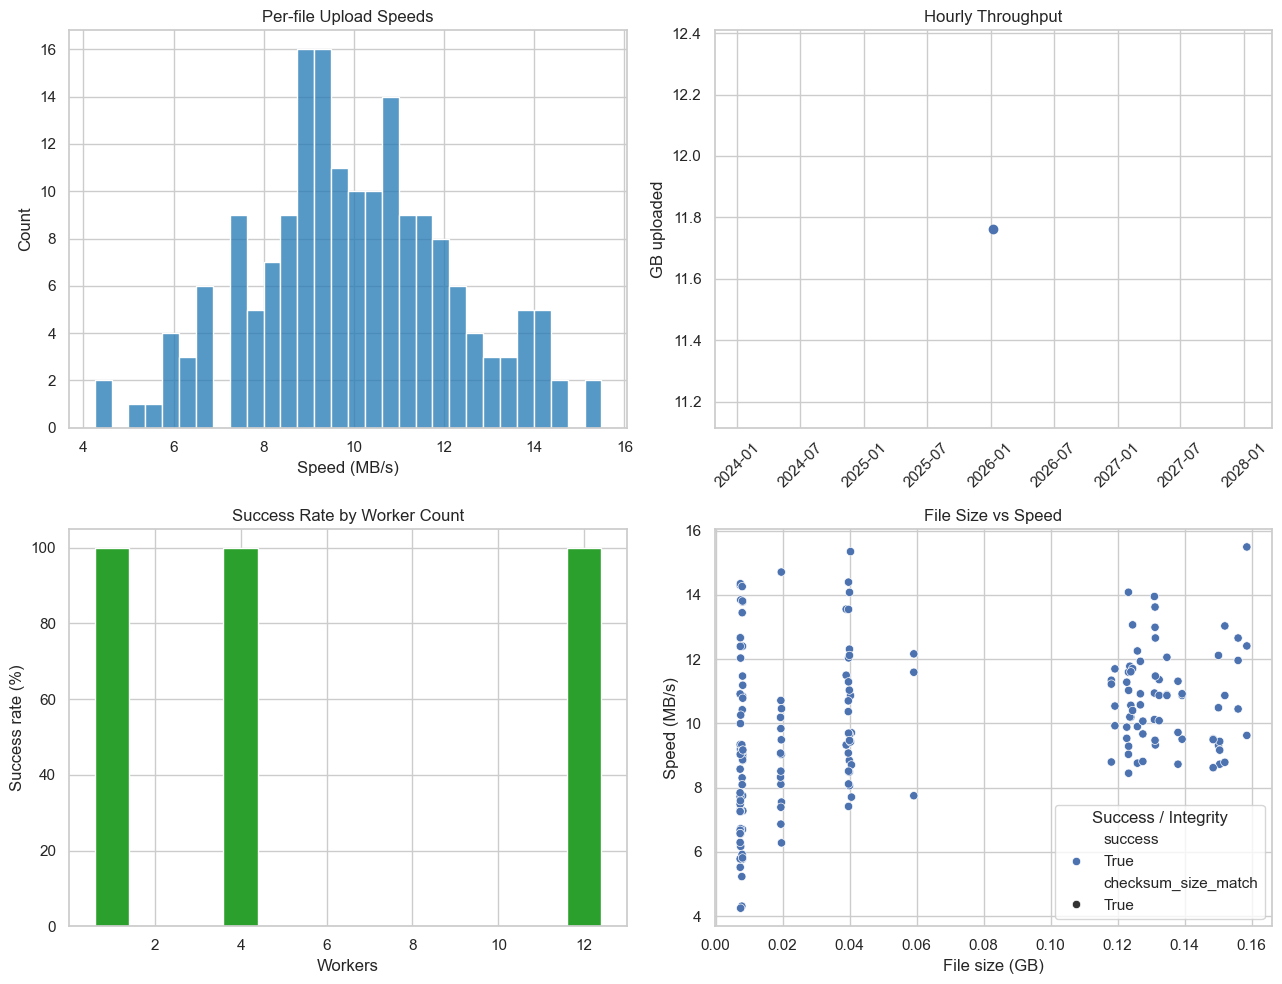


Integrity check: all uploaded files matched size & checksum.


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid")

stats_path = Path("../stats/upload_stats.csv").resolve()
if not stats_path.exists():
    stats_path = Path("upload_stats_async.csv").resolve()
if not stats_path.exists():
    raise FileNotFoundError(f"Stats file not found: {stats_path}")

stats_mode = "async" if stats_path.name.endswith("_async.csv") else "sync"
print(f"Loaded {stats_mode} stats from {stats_path}")

df = pd.read_csv(stats_path, parse_dates=["timestamp"])
if df.empty:
    raise ValueError("Stats file is empty; nothing to analyse.")

df["hour_bucket"] = df["timestamp"].dt.floor("h")
df["size_GB"] = df["size_bytes"] / 1024**3
df["speed_MBps"] = df["upload_speed_Bps"].clip(lower=0) / 1024**2
df["duration_min"] = df["upload_seconds"] / 60
df["is_metadata_file"] = df["file_name"].str.endswith(".json")

summary = {
    "files": len(df),
    "datasets": df["dataset_folder"].nunique(),
    "records": df["record_id"].nunique(),
    "data_GB": df["size_GB"].sum(),
    "median_speed_MBps": df["speed_MBps"].median(),
    "success_rate_pct": df["success"].mean() * 100,
    "integrity_rate_pct": df["checksum_size_match"].mean() * 100,
}
print("=== Upload summary ===")
for key, value in summary.items():
    print(f"{key:>20}: {value:.2f}" if isinstance(value, float) else f"{key:>20}: {value}")

dataset_summary = (
    df.groupby("dataset_folder")
    .agg(
        files=("file_name", "count"),
        data_GB=("size_GB", "sum"),
        avg_speed_MBps=("speed_MBps", "mean"),
        duration_min=("duration_min", "sum"),
        success_rate=("success", "mean"),
        integrity_rate=("checksum_size_match", "mean"),
    )
    .sort_values("data_GB", ascending=False)
)
print("\nTop datasets by transferred data (GB):")
display(
    dataset_summary.head(10).style.format(
        {
            "data_GB": "{:.2f}",
            "avg_speed_MBps": "{:.2f}",
            "duration_min": "{:.1f}",
            "success_rate": "{:.0%}",
            "integrity_rate": "{:.0%}",
        }
    )
)

worker_summary = (
    df.groupby("workers")
    .agg(
        files=("file_name", "count"),
        data_GB=("size_GB", "sum"),
        avg_speed_MBps=("speed_MBps", "mean"),
        success_rate=("success", "mean"),
    )
    .reset_index()
)
print("\nWorker utilisation snapshot:")
display(worker_summary.style.format({"data_GB": "{:.2f}", "avg_speed_MBps": "{:.2f}", "success_rate": "{:.0%}"}))

hourly = (
    df.groupby("hour_bucket")
    .agg(
        files=("file_name", "count"),
        data_GB=("size_GB", "sum"),
        avg_speed_MBps=("speed_MBps", "mean"),
    )
    .reset_index()
)

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
sns.histplot(df["speed_MBps"], bins=30, ax=axes[0, 0], color="tab:blue")
axes[0, 0].set_title("Per-file Upload Speeds")
axes[0, 0].set_xlabel("Speed (MB/s)")

axes[0, 1].plot(hourly["hour_bucket"], hourly["data_GB"], marker="o")
axes[0, 1].set_title("Hourly Throughput")
axes[0, 1].set_ylabel("GB uploaded")
axes[0, 1].tick_params(axis="x", rotation=45)

axes[1, 0].bar(worker_summary["workers"], worker_summary["success_rate"] * 100, color="tab:green")
axes[1, 0].set_title("Success Rate by Worker Count")
axes[1, 0].set_xlabel("Workers")
axes[1, 0].set_ylabel("Success rate (%)")

sns.scatterplot(
    data=df,
    x="size_GB",
    y="speed_MBps",
    hue="success",
    style="checksum_size_match",
    ax=axes[1, 1],
)
axes[1, 1].set_title("File Size vs Speed")
axes[1, 1].set_xlabel("File size (GB)")
axes[1, 1].set_ylabel("Speed (MB/s)")
axes[1, 1].legend(title="Success / Integrity", loc="lower right")

fig.tight_layout()
plt.show()

mismatches = df[~df["checksum_size_match"]]
if mismatches.empty:
    print("\nIntegrity check: all uploaded files matched size & checksum.")
else:
    print(f"\nIntegrity check: {len(mismatches)} file(s) failed size/checksum validation.")
    display(
        mismatches[
            ["timestamp", "dataset_folder", "file_name", "size_bytes", "remote_size_bytes", "checksum_md5", "remote_checksum"]
        ].head(20)
    )


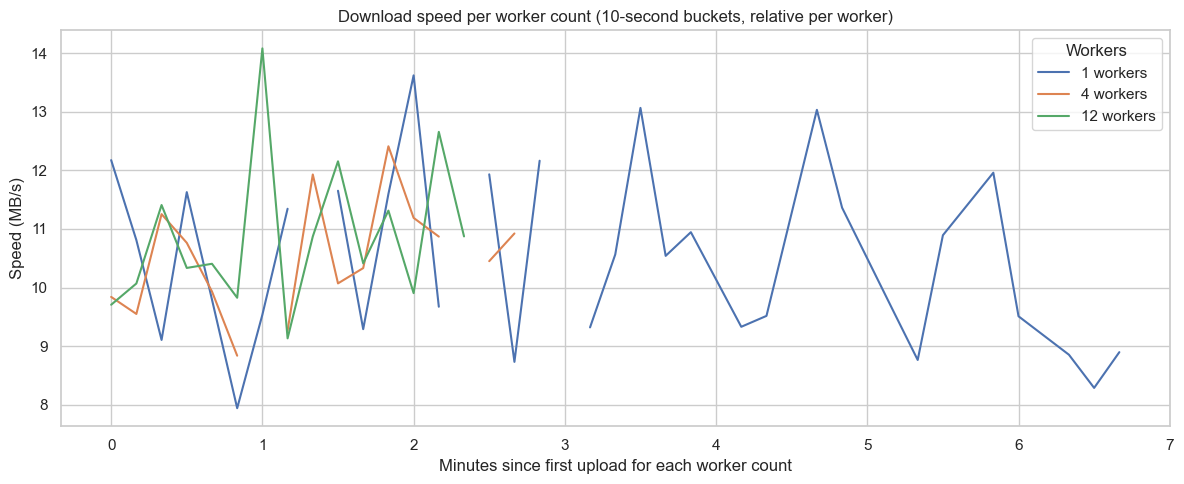

In [5]:

df["bucket_10s"] = df["timestamp"].dt.floor("10s")
bucket_stats = (
    df.groupby(["bucket_10s", "workers"])["speed_MBps"]
    .mean()
    .reset_index()
    .sort_values("bucket_10s")
)
bucket_stats["elapsed_min"] = (
    bucket_stats.groupby("workers")["bucket_10s"]
    .transform(lambda col: (col - col.min()).dt.total_seconds() / 60)
)
pivot = bucket_stats.pivot(index="elapsed_min", columns="workers", values="speed_MBps")

plt.figure(figsize=(12, 5))
plt.plot(pivot.index, pivot.values)
plt.legend([f"{col} workers" for col in pivot.columns], title="Workers", loc="upper right")
plt.title("Download speed per worker count (10-second buckets, relative per worker)")
plt.xlabel("Minutes since first upload for each worker count")
plt.ylabel("Speed (MB/s)")
plt.tight_layout()
plt.show()


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_16120\3251519074.py:19: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Lenovo\anaconda3\envs\test\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


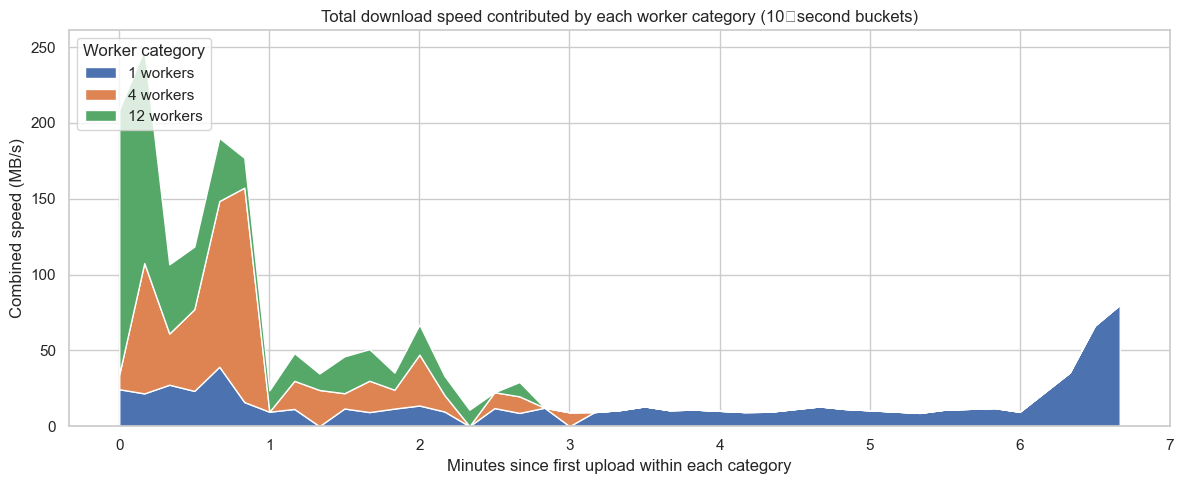

In [7]:

bucket_totals = (
    df.groupby(["bucket_10s", "workers"])["speed_MBps"]
    .sum()
    .reset_index()
    .sort_values("bucket_10s")
)
bucket_totals["elapsed_min"] = (
    bucket_totals.groupby("workers")["bucket_10s"]
    .transform(lambda col: (col - col.min()).dt.total_seconds() / 60)
)
total_pivot = bucket_totals.pivot(index="elapsed_min", columns="workers", values="speed_MBps").fillna(0)

plt.figure(figsize=(12, 5))
plt.stackplot(total_pivot.index, total_pivot.T, labels=[f"{w} workers" for w in total_pivot.columns])
plt.legend(title="Worker category", loc="upper left")
plt.title("Total download speed contributed by each worker category (10‑second buckets)")
plt.xlabel("Minutes since first upload within each category")
plt.ylabel("Combined speed (MB/s)")
plt.tight_layout()
plt.show()

